<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-17-feature-scaling-norm-std?scriptVersionId=339873021" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🤖 ML 17 — Feature Scaling: Normalization & Standardization

### **Master Normalization & Standardization for Machine Learning.**

---


# 🚀 Introduction

In many Machine Learning problems, features can have completely different scales. For example, one feature might represent **age (20–80)** while another represents **salary (20,000–500,000)**. Models that rely on distance or gradient optimization can become biased toward larger-valued features if the data isn't properly scaled.

In this notebook, you'll learn **Feature Scaling**—an essential preprocessing step that transforms numerical features into comparable ranges without changing the underlying information. You'll explore the two most widely used scaling techniques:

* 📏 **Normalization (Min-Max Scaling)** – scales values to a fixed range, usually **0 to 1**.
* 📊 **Standardization (Z-Score Scaling)** – transforms data to have a **mean of 0** and a **standard deviation of 1**.

By the end of this notebook, you'll understand **when to use each technique, how to implement them with Scikit-learn, and why feature scaling is crucial for building accurate and efficient Machine Learning models.** 🚀

<div align="center">
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQzoZo606dEENqPU8nfSK64ejJ5roYx9cKeaiO67JLqSQ&s=10" width=500>
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcScPCB7aIIdU1_aiE_SL4cTQWuOcB5LjUg-rrlz9oiUTQ&s=10" width=500>
</div>


---
# 📦 Importing Required Libraries

We'll import the essential libraries needed for data manipulation, visualization, and feature scaling throughout this notebook.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

---

# 📊 Part 1 — Standardization

## 1. Reading Data

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ahmedfakhar123/customer-purchase-prediction-dataset/Social_Network_Ads.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


## 2. Train test split

In [3]:
# Extracting Features
X = df[["Age", "EstimatedSalary"]]

# Setting Target
y = df["Purchased"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

X_train.shape, X_test.shape

((320, 2), (80, 2))

## 3. Scaling Data

In [5]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

scale.fit(X_train)

X_train_scaled = pd.DataFrame(scale.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scale.transform(X_test), columns=X_test.columns)

In [6]:
X_train

,Age,EstimatedSalary
85,31,118000
69,31,68000
203,41,71000
379,58,23000
261,36,144000
...,...,...
306,51,134000
165,18,86000
7,32,150000
219,59,143000


In [7]:
X_train_scaled

,Age,EstimatedSalary
0,-0.705628,1.365600
1,-0.705628,-0.078333
2,0.264724,0.008303
3,1.914322,-1.377873
4,-0.220452,2.116445
...,...,...
315,1.235076,1.827658
316,-1.967085,0.441483
317,-0.608592,2.289717
318,2.011357,2.087566


In [8]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,38.3,70712.5
std,10.3,34681.9
min,18.0,15000.0
25%,31.0,43000.0
50%,37.0,71000.0
75%,46.0,88000.0
max,60.0,150000.0


In [9]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,0.0
std,1.0,1.0
min,-2.0,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.1,2.3


## 4. Effect of Scaling

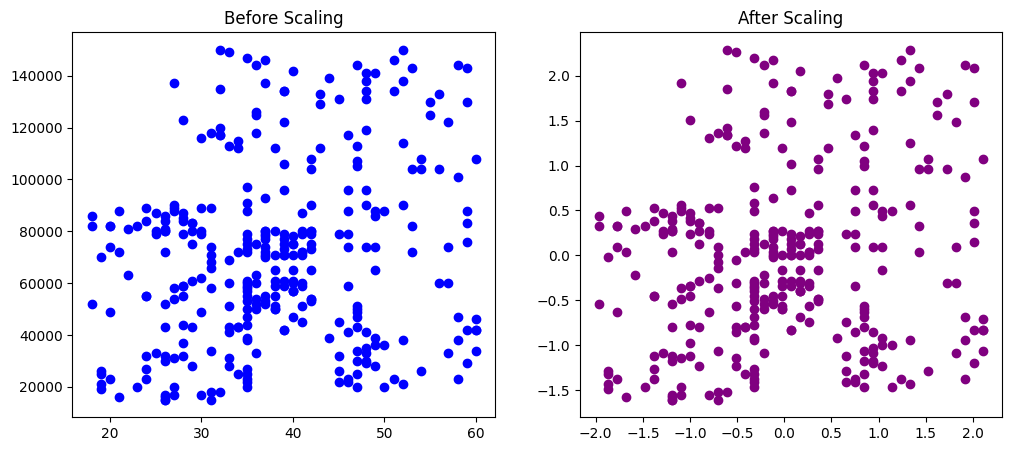

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.scatter(X_train["Age"], X_train["EstimatedSalary"], color="blue")
ax1.set_title("Before Scaling")

# After Scaling
ax2.scatter(X_train_scaled["Age"], X_train_scaled["EstimatedSalary"], color="purple")
ax2.set_title("After Scaling")

plt.show()

## 5. Comparison of Distributions

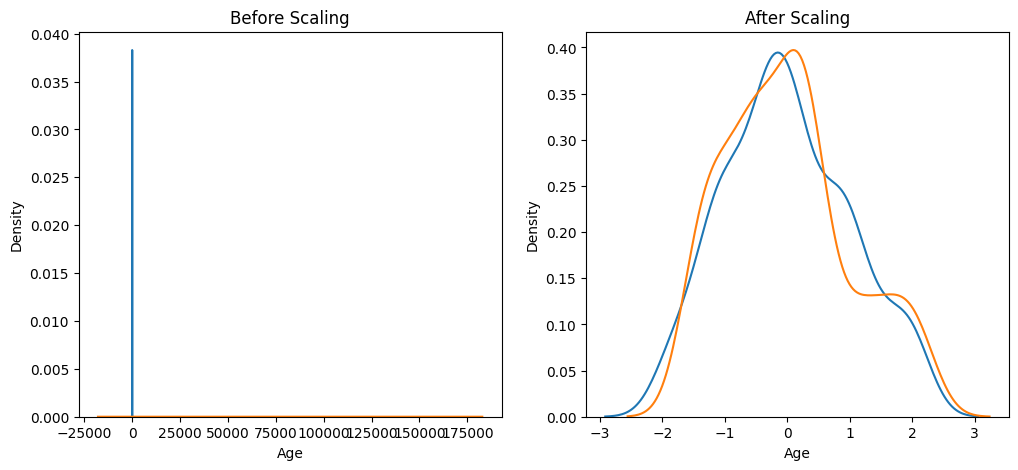

In [11]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"], ax=ax1)
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1)

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"], ax=ax2)
sns.kdeplot(X_train_scaled["EstimatedSalary"], ax=ax2)

plt.show()

## 6. Why scaling is important?

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model_scaled = LogisticRegression()

model.fit(X_train, y_train)
model_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [13]:
y_pred = model.predict(X_test)
y_pred_scaled = model_scaled.predict(X_test_scaled)

In [14]:
from sklearn.metrics import accuracy_score

print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.8375
Scaled 0.8375


>**Feature scaling does not always increase accuracy**. Its primary purpose is to put features on a similar scale, allowing optimization-based algorithms such as Logistic Regression to converge more efficiently. Depending on the dataset and train-test split, the accuracy may increase, decrease slightly, or remain almost unchanged.

## 7. Effect of Outlier

In [15]:
df = pd.concat([df, pd.DataFrame({'Age':[1,90,100],'EstimatedSalary':[10,250000,350000],'Purchased':[0,1,1]})],ignore_index=True)
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510.0,Male,19,19000,0
1,15810944.0,Male,35,20000,0
2,15668575.0,Female,26,43000,0
3,15603246.0,Female,27,57000,0
4,15804002.0,Male,19,76000,0
...,...,...,...,...,...
398,15755018.0,Male,36,33000,0
399,15594041.0,Female,49,36000,1
400,NaN,NaN,1,10,0
401,NaN,NaN,90,250000,1


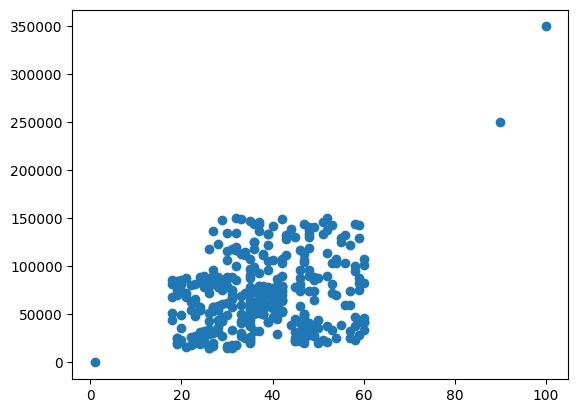

In [16]:
plt.scatter(df['Age'], df['EstimatedSalary'])
plt.show()

In [17]:
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

X_train.shape, X_test.shape

((322, 2), (81, 2))

In [18]:
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

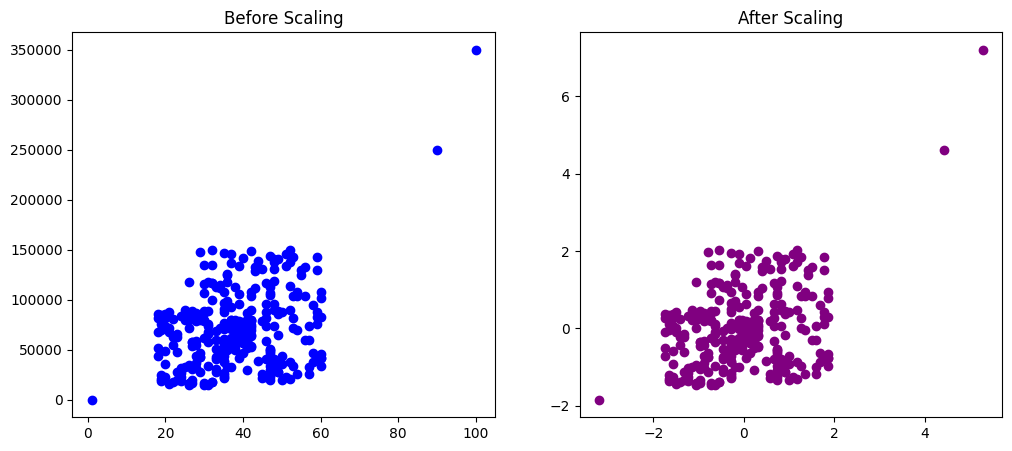

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'], color="blue")
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='purple')
ax2.set_title("After Scaling")

plt.show()

### Does Feature Scaling Remove Outliers?

> Feature scaling **does not remove outliers**. It only changes the scale of the data while preserving the relative distance between values. Outliers remain outliers after scaling, although their numerical values change. To deal with outliers, separate techniques such as **outlier removal, capping, or robust scaling** should be used.
